<a href="https://colab.research.google.com/github/cibelerusso/Aprendizado_de_Maquina/blob/main/Codigos%20em%20Python/Aprendizado_Supervisionado_Arvore_de_decis%C3%A3o_JogarTenis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SME0829 Aprendizado de Máquina


por **Cibele Russo**

**ICMC/USP - São Carlos SP**



## Exemplo Árvore de decisão



In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import random

random.seed(1)

# Carregando os dados
dados = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Datasets/refs/heads/main/jogartenis_aumentado.csv')
dados


,Unnamed: 0,Tempo,Temperatura,Umidade,Vento,Joga
0,0,Ensolarado,23,70,Não,Sim
1,1,Chuvoso,18,82,Não,Sim
2,2,Chuvoso,26,60,Sim,Não
3,3,Nublado,18,96,Não,Sim
4,4,Ensolarado,22,80,Sim,Sim
...,...,...,...,...,...,...
495,495,Ensolarado,20,91,Sim,Não
496,496,Nublado,30,70,Não,Sim
497,497,Ensolarado,25,82,Não,Sim
498,498,Chuvoso,26,85,Sim,Não


In [85]:
dados['Tempo'] = dados['Tempo'].map({
    'Ensolarado': 1,
    'Nublado': 2,
    'Chuvoso': 3
})

dados['Vento'] = dados['Vento'].map({
    'Sim': 1,
    'Não': 0
})

dados['Joga'] = dados['Joga'].map({
    'Sim': 1,
    'Não': 0
})

In [86]:
dados

,Unnamed: 0,Tempo,Temperatura,Umidade,Vento,Joga
0,0,1,23,70,0,1
1,1,3,18,82,0,1
2,2,3,26,60,1,0
3,3,2,18,96,0,1
4,4,1,22,80,1,1
...,...,...,...,...,...,...
495,495,1,20,91,1,0
496,496,2,30,70,0,1
497,497,1,25,82,0,1
498,498,3,26,85,1,0


In [87]:
# Separa as preditoras (X) e a resposta (y)
X = dados.drop('Joga', axis=1)
y = dados['Joga']

In [88]:
# dados de treinamento e teste: 80% para treinamento e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [89]:
X_train

,Unnamed: 0,Tempo,Temperatura,Umidade,Vento
5,5,1,21,85,1
116,116,3,24,78,0
45,45,2,22,99,0
16,16,1,26,94,0
462,462,3,28,87,1
...,...,...,...,...,...
106,106,2,19,73,0
270,270,3,23,82,1
348,348,1,18,79,1
435,435,3,18,98,1


In [90]:
# Cria uma árvore de decisão
arvore = DecisionTreeClassifier(max_depth=5, criterion='entropy')

# Treina a árvore de decisão usando os dados de treinamento
arvore.fit(X_train, y_train)

# Usa a árvore de decisão para prever os rótulos da base de teste
y_pred = arvore.predict(X_test)
y_pred


array([1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [91]:
y_test

,Joga
361,1
73,0
374,0
155,1
104,0
...,...
266,1
23,1
222,1
261,1


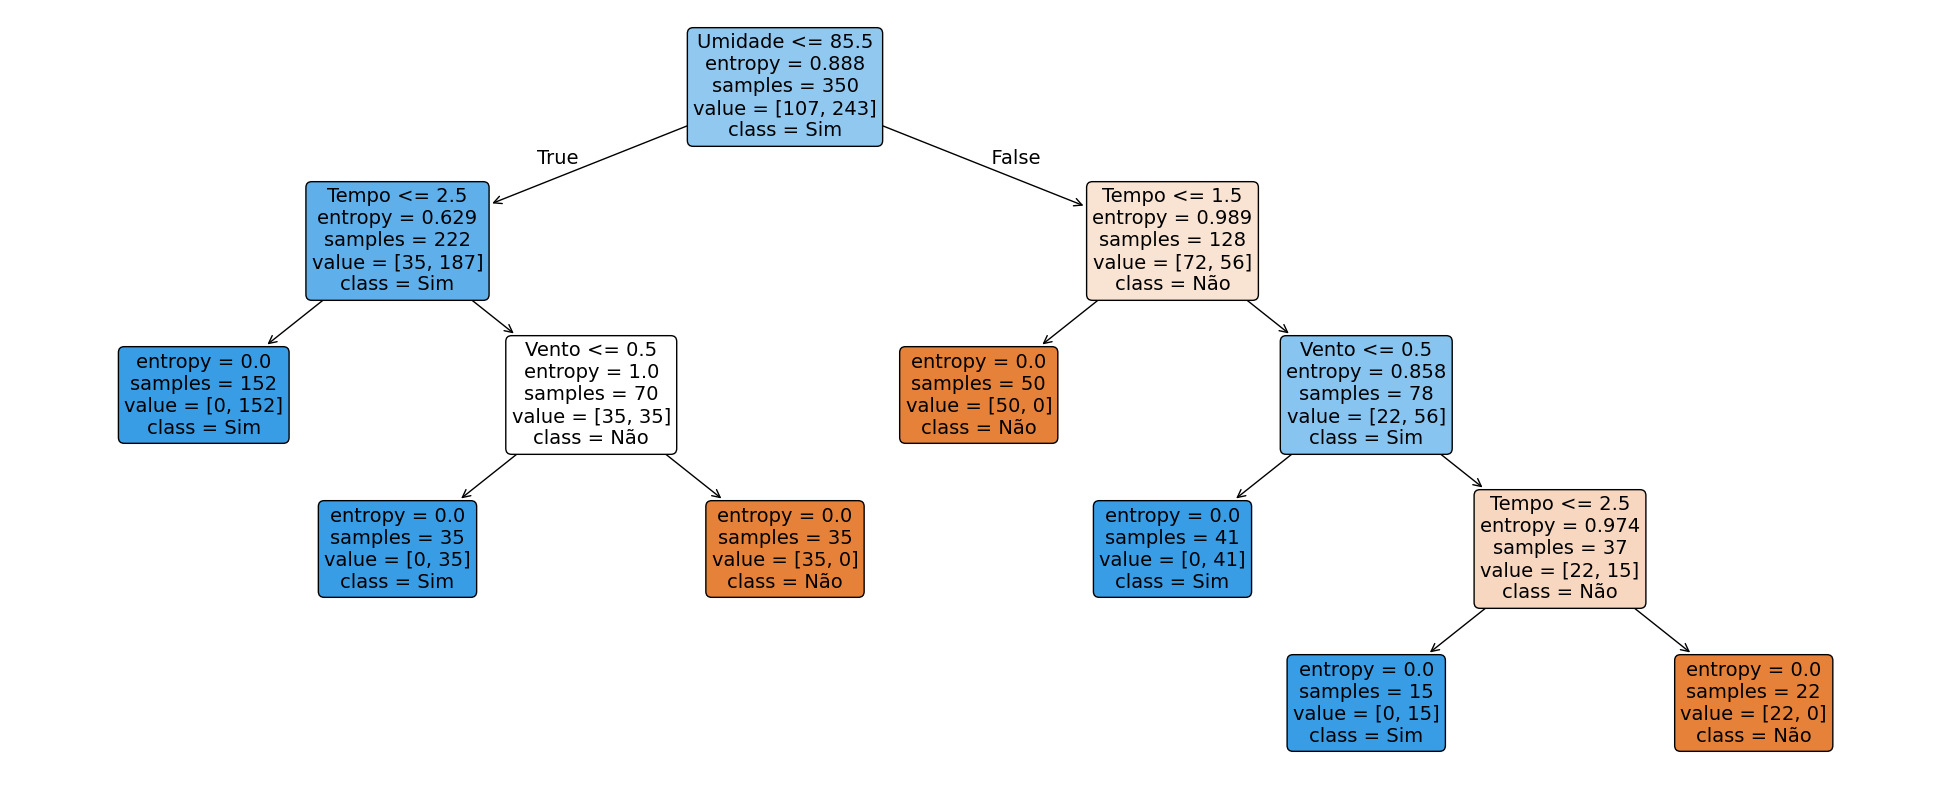

In [92]:
plt.figure(figsize=(25, 10))

a = plot_tree(
    arvore,
    feature_names=X_train.columns,
    class_names=['Não', 'Sim'],
    filled=True,
    rounded=True,
    fontsize=14
)

In [93]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Acurácia
acc = accuracy_score(y_test, y_pred)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(acc,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 1.0

Precisão (para a classe 1): 1.0
Recall (para a classe 1): 1.0
F1-score (para a classe 1): 1.0

Precisão (para a classe 0): 1.0
Recall (para a classe 0): 1.0
F1-score (para a classe 0): 1.0


# Escolha da árvore por validação cruzada

In [94]:
from sklearn.model_selection import GridSearchCV

# Uso da validação cruzada para encontar a melhor árvore
param_grid = {
    'max_depth': range(2, 4),
    'min_samples_split': range(2, 3),
    'min_samples_leaf': range(2, 8)
}

# Realiza a busca em grid com cross-validation para encontrar a melhor árvore
grid = GridSearchCV(arvore, param_grid, cv=5)
grid.fit(X_train, y_train)

# Usa a árvore de decisão para prever os rótulos da base de teste
y_pred = grid.predict(X_test)

# Melhor árvore escolhida
print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Acurácia da melhor árvore: {grid.best_score_}")

Melhores parâmetros: {'max_depth': 3, 'min_samples_leaf': 7, 'min_samples_split': 2}
Acurácia da melhor árvore: 0.9571428571428573


In [95]:
# Acurácia
acc = accuracy_score(y_test, y_pred)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(acc,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.953

Precisão (para a classe 1): 1.0
Recall (para a classe 1): 0.932
F1-score (para a classe 1): 0.965

Precisão (para a classe 0): 0.87
Recall (para a classe 0): 1.0
F1-score (para a classe 0): 0.931


# Métodos ensemble
# Exemplo Bagging

In [96]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Inicializa o classificador por árvore de decisão
tree = DecisionTreeClassifier(random_state=42)

# Inicializa o classificador Bagging
bagging = BaggingClassifier(
    estimator=tree,      # antes era base_estimator
    n_estimators=20,
    random_state=42
)

# Ajusta o classificador aos dados de treinamento
bagging.fit(X_train, y_train)

# Prediz a resposta para a base de teste
y_pred = bagging.predict(X_test)

# Avalia a performance
score = bagging.score(X_test, y_test)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(score, 3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("\nPrecisão (classe 1):", np.round(precision, 3))
print("Recall (classe 1):", np.round(recall, 3))
print("F1-score (classe 1):", np.round(f1, 3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)

print("\nPrecisão (classe 0):", np.round(precision, 3))
print("Recall (classe 0):", np.round(recall, 3))
print("F1-score (classe 0):", np.round(f1, 3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 1.0

Precisão (classe 1): 1.0
Recall (classe 1): 1.0
F1-score (classe 1): 1.0

Precisão (classe 0): 1.0
Recall (classe 0): 1.0
F1-score (classe 0): 1.0


# Exemplo Boosting

In [97]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Inicializa o classificador por árvore de decisão
tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# Inicializa o classificador AdaBoost
adaboost = AdaBoostClassifier(
    estimator=tree,      # antes era base_estimator
    n_estimators=20,
    learning_rate=1,
    random_state=42
)

# Ajusta o classificador AdaBoost aos dados de treinamento
adaboost.fit(X_train, y_train)

# Prediz para a base de teste
y_pred = adaboost.predict(X_test)

# Avalia a performance
score = adaboost.score(X_test, y_test)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(score, 3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("\nPrecisão (classe 1):", np.round(precision, 3))
print("Recall (classe 1):", np.round(recall, 3))
print("F1-score (classe 1):", np.round(f1, 3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)

print("\nPrecisão (classe 0):", np.round(precision, 3))
print("Recall (classe 0):", np.round(recall, 3))
print("F1-score (classe 0):", np.round(f1, 3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.953

Precisão (classe 1): 1.0
Recall (classe 1): 0.932
F1-score (classe 1): 0.965

Precisão (classe 0): 0.87
Recall (classe 0): 1.0
F1-score (classe 0): 0.931


# Exemplo Florestas aleatórias


In [98]:
from sklearn.ensemble import RandomForestClassifier

# Ajusta um classificador por florestas aleatórias
clf = RandomForestClassifier(n_estimators=200, random_state=10)
clf.fit(X_train, y_train)

# Obtém predições para a base de teste
y_pred = clf.predict(X_test)

# Avalia a performance do classificador por florestas aleatórias nos dados de teste
acc = accuracy_score(y_test, y_pred)



print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(acc,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 1.0

Precisão (para a classe 1): 1.0
Recall (para a classe 1): 1.0
F1-score (para a classe 1): 1.0

Precisão (para a classe 0): 1.0
Recall (para a classe 0): 1.0
F1-score (para a classe 0): 1.0
